In [1]:
import phasr as phr
import numpy as np
import matplotlib.pyplot as plt
from phasr.dirac_solvers.post_processing.overlap_integrals import nabla_dot_plus, nabla_dot_minus
from phasr.physical_constants import masses
from scipy import integrate
from mpmath import diff
from IPython.display import display, Math
from collections import defaultdict
mmu=masses.mmu #MeV
mpi=(masses.mpipl+masses.mpi0)/2 #MeV
mpi0=masses.mpi0 #MeV
hc=phr.constants.hc #MeV*fm
hbar=phr.constants.hbar #MeV*s

def derivative(func,x,dx=1e-6):
    return (func(x+dx)-func(x-dx))/(2*dx)

In [2]:
# Fill in with your SMEFT parameters
# Lagrangian of (3.5) in arXiv:???

Lambda=1e7 # scale of new physics.
mq=np.array([2.16,4.67,93]) #for u,d,s quarks. 

# Wilson coefficients for the effective operators of new physics
C={ 'R':{
        'S':np.array([1.2,1.7,1.])*0.1, # for u,d,s quarks
        'P':np.array([mq[0],-mq[1],0.])*0.1,
        'V':np.array([1.,1.,1.])*0.1,
        'A':np.array([1.,-1.,0.])*0.1,
        'T':np.array([1.,1.,1.])*0.1,
        'GG':1.0,
        'GGtilde':1.0,
        'D':1e-14
    },
    'L':{
        'S':np.array([1.2,1.7,1.])*0.1, # for u,d,s quarks
        'P':np.array([mq[0],-mq[1],0.])*0.1,
        'V':np.array([1.,1.,1.])*0.1,
        'A':np.array([1.,-1.,0.])*0.1,
        'T':np.array([1.,1.,1.])*0.1,
        'GG':1.0,
        'GGtilde':1.0,
        'D':1e-14
    }
}

In [3]:
#Form factors values from arXiv:2007.08529v2
# Isospin symmetry is assumed
kappa_p=1.79284734462
kappa_n=-1.91304273
r2p=0.7071
r2n=-0.1161
kappa_sN=-0.017
r2s=-0.0048
gA=1.27641 #triplet
# axial couplings from 2605.06559
gA0=0.355 #singlet
gAsN=-0.0325 
r2A=0.46 # fm^2
F1Tup=0.784;F1Tdn=F1Tup
F1Tdp=-0.204;F1Tun=F1Tdp
F1TsN=-0.0027
F2Tup=-1.5;F2Tdn=F2Tup
F2Tdp=0.5;F2Tun=F2Tdp
F2TsN=0.009
F3Tup=0.1;F3Tdn=F3Tup
F3Tdp=-0.6;F3Tun=F3Tdp
F3TsN=-0.004
fu_p=20.8e-3
fd_p=41.1e-3
fu_n=18.9e-3
fd_n=45.1e-3
fs_N=43e-3
fQ_N=68e-3
ksi_ud=0.35
sigma_dot=0.27e-3
sigma_s_dot=0.3e-3
fu_pi=0.315
fd_pi=0.685

#From https://arxiv.org/pdf/2204.06005
aN_tilde=-390 # MeV


# Masses are in MeV
mp=938.27 
mn=939.57 
mN=(mp+mn)/2
mpi=(139.57+134.98)/2
mmu=105.66
meta=547.86
metap=957.78
gpiNN=np.sqrt(4*np.pi*13.7)
Fpi=92.28 # MeV
alpha=1/137.036
eta_e=-1 #sign convention for e-charge in the lagrangian



In [4]:
# Form factor definitions
#scalar FFs
def fq_N(t,nuc):
    if nuc=='p':
        return np.array([fu_p+(1-ksi_ud)/(2*mN)*sigma_dot*t, fd_p+(1+ksi_ud)/(2*mN)*sigma_dot*t, fs_N+sigma_s_dot/(mN)*t])
    elif nuc=='n':
        return np.array([fu_n+(1-ksi_ud)/(2*mN)*sigma_dot*t, fd_n+(1+ksi_ud)/(2*mN)*sigma_dot*t, fs_N+sigma_s_dot/(mN)*t])

# vector FFs
r2eff_p=r2p/hc**2-3*kappa_p/(2*mN**2)
r2eff_n=r2n/hc**2-3*kappa_n/(2*mN**2)

def F1(t,nuc):
    if nuc=='p':
        return 1+r2eff_p/6*t
    elif nuc=='n':
        return r2eff_n/6*t

def F2(t,nuc):
    if nuc=='p':
        return kappa_p
    elif nuc=='n':
        return kappa_n

def GEs_N(t):
    return 0.+r2s/6.*t
def GMs_N(t):
    return kappa_sN
def F1s_N(t):
    return (GEs_N(t)-t/(4*mN**2)*GMs_N(t))/(1-t/(4*mN**2))
def F2s_N(t):
    return (GMs_N(t)-GEs_N(t))/(1-t/(4*mN**2))
# Assuming isospin symmetry
def F1q_N(t,nuc):
    if nuc=='p':
        return np.array([2*F1(t,'p')+F1(t,'n')+F1s_N(t), F1(t,'p')+2*F1(t,'n')+F1s_N(t), F1s_N(t)])
    elif nuc=='n':
        return np.array([F1(t,'p')+2*F1(t,'n')+F1s_N(t), 2*F1(t,'p')+F1(t,'n')+F1s_N(t), F1s_N(t)])

def F2q_N(t,nuc):
    if nuc=='p':
        return np.array([2*F2(t,'p')+F2(t,'n')+F2s_N(t), F2(t,'p')+2*F2(t,'n')+F2s_N(t), F2s_N(t)])
    elif nuc=='n':
        return np.array([F2(t,'p')+2*F2(t,'n')+F2s_N(t), 2*F2(t,'p')+F2(t,'n')+F2s_N(t), F2s_N(t)])

# axial-vector FFs
def GA(t,nuc,index):
    if index==3:
        if nuc=='p':
            return gA*(1+r2A*t/6/hc**2)
        elif nuc=='n':
            return -gA*(1+r2A*t/6/hc**2)
    if index==8:
        return (gA0-3*gAsN)/np.sqrt(3)
    if index==0:
        return gA0 
    else:
        raise ValueError('Invalid index for axial FF. Must be 0,3 or 8.')

def octet_to_quark(G3,G8,G0): # Converts from SU(3) octet basis to quark basis.
    return np.array([1/2*G3+1/(2*np.sqrt(3))*G8+1/3*G0,
                     -1/2*G3+1/(2*np.sqrt(3))*G8+1/3*G0,
                     -1/np.sqrt(3)*G8+1/3*G0])

def GAq_N(t,nuc):
    return octet_to_quark(G3=GA(t,nuc,3),G8=GA(t,nuc,8),G0=GA(t,nuc,0))

def GP(t,nuc,index):
    if index==3:
        if nuc=='p':
            return -4*mN*gpiNN*Fpi/(t-mpi**2)-2/3.*gA*mN**2*r2A/hc**2
        elif nuc=='n':
            return 4*mN*gpiNN*Fpi/(t-mpi**2)+2/3.*gA*mN**2*r2A/hc**2
    if index==8:
        return -4*mN**2*GA(0,nuc,8)/(t-meta**2)
    if index==0:
        return 0. #unknown, but expected to be small due to the large mass of eta prime.

def GPq_N(t,nuc):
    return octet_to_quark(G3=GP(t,nuc,3),G8=GP(t,nuc,8),G0=GP(t,nuc,0))

# Tensor FFs
def F1Tq_N(t,nuc):
    if nuc=='p':
        return np.array([F1Tup, F1Tdp,F1TsN])
    elif nuc=='n':
        return np.array([F1Tun, F1Tdn,F1TsN])
def F2Tq_N(t,nuc):
    if nuc=='p':
        return np.array([F2Tup, F2Tdp,F2TsN])
    elif nuc=='n':
        return np.array([F2Tun, F2Tdn,F2TsN])
def F3Tq_N(t,nuc):
    if nuc=='p':
        return np.array([F3Tup, F3Tdp,F3TsN])
    elif nuc=='n':
        return np.array([F3Tun, F3Tdn,F3TsN])
    
# Pseudo-scalar FFs. Given by ward identity https://journals.aps.org/prd/pdf/10.1103/PhysRevD.102.074018
def G5(t,nuc,index):
    if index==3 or index==8:
        return GA(t,nuc,index)+ t/(4*mN**2)*GP(t,nuc,index)
    elif index==0:
        return GA(t,nuc,index)+ t/(4*mN**2)*GP(t,nuc,index)+3*aN_tilde/(2*mN) #include GGtilde contribution

def G5q_N(t,nuc):
    return octet_to_quark(G3=G5(t,nuc,3),G8=G5(t,nuc,8),G0=G5(t,nuc,0))


#Gluon FFs
def fGG(t):
    return -12*np.pi*mN*fQ_N

#Gluontilde FFs
def fGGtilde(t):
    return 4*np.pi*aN_tilde

Text(0.5, 0, 'q (MeV)')

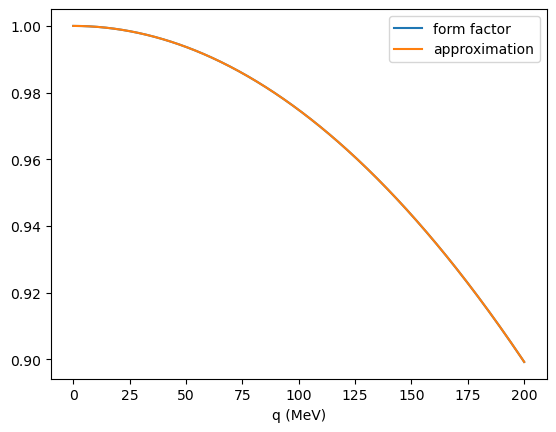

In [5]:
# Ploting nucleon form factors
q=np.linspace(0.,200,500)
t=-q**2

func=lambda t: F1(t,'p')
fpp=derivative(func,-105.**2)
plt.plot(q,func(t),label='form factor')
f0=func(-105.**2);fpp=derivative(func,-105.**2)
plt.plot(q,f0+fpp*(t+105.**2),label='approximation')
#plt.plot(q,GP(t,'p',8),label='2')
plt.legend()
plt.xlabel('q (MeV)')

In [6]:
# Nuclear shell model for Al-27, from https://arxiv.org/pdf/2204.06005  
FF_dict={'shell_model':{}}
Z=13;N=14
b=1.8420
c={'FM0+':np.array([Z+N,-11.3343,0.837814]),
   'FM0-':np.array([Z-N,0.666696,-0.0858552]),
   'FPhipp0+':0.7*np.array([-4.98975,0.997985]),
   'FPhipp0-':0.7*np.array([0.303398,-0.0606814]),
   'FSigmap1p':2.6*np.array([0.217688,-0.199127,0.0274599]),
   'FSigmap3p':2.6*np.array([0.,-0.0543796,0.00651646]),
   'FSigmap5p':2.6*np.array([0.,0.,0.0277341]),
   'FSigmap1n':2.6*np.array([0.0255784,-0.00985665,-0.00150251]),
   'FSigmap3n':2.6*np.array([0.,0.000280434,-0.000488419]),
   'FSigmap5n':2.6*np.array([0.,0.,0.000128524]),
   'FSigmapp1p': 2.6*np.array([0.153928,-0.0262479,0.00103769]),
   'FSigmapp3p': 2.6*np.array([0.,-0.0470943,-0.00206298]),
   'FSigmapp5p': 2.6*np.array([0.,0.,0.0253177]),
   'FSigmapp1n': 2.6*np.array([0.0180868,-0.022234,0.00278141]),
   'FSigmapp3n': 2.6*np.array([0.,0.000242867,0.000103865]),
   'FSigmapp5n': 2.6*np.array([0.,0.,0.000117327])}
for key in ['FM0','FPhipp0']:
    c[key+'p']=(c[key+'+']+c[key+'-'])/2.
    c[key+'n']=(c[key+'+']-c[key+'-'])/2.
    c.pop(key+'+')
    c.pop(key+'-')
for multipole_key in c:
    coeffs = c[multipole_key]
    FF_dict['shell_model'][multipole_key] = lambda q, coeffs=coeffs: np.exp(-(q*b)**2/(2*hc**2)/2.) * sum(
        coeffs[i] * ((q*b)**2/(2*hc**2))**(i) for i in range(len(coeffs))
    )

In [7]:
# Load structure functions
# r_cut determines when the continuation of currents to high energies takes place
# q_cutoff is the momentum cutoff for the structure functions

# Use float numbers!
r_cut={'M0': 7., 'M2':6.,'M4':5.3, 'Phipp0':6.,'Phipp2': 20.,'Phipp4': 20.,
          'Sigmap1': 20., 'Sigmap3': 20., 'Sigmap5': 15., 'Sigmapp1': 20., 'Sigmapp3': 20., 'Sigmapp5': 12.5,
          'Delta1':6.,'Delta3': 5.,'Delta5': 4.5,
          '2dotM0': 6.5, '2dotM2':6.,'2dotM4':5.5, '2dotPhipp0':6.,'2dotPhipp2': 5.5,'2dotPhipp4': 4.7,
          '2dotSigmap1': 6.0, '2dotSigmap3': 5.5, '2dotSigmap5': 4.2, '2dotSigmapp1': 4.0, '2dotSigmapp3': 6.5, '2dotSigmapp5': 5.5,
          '4dotSigmapp1': 4.5, '4dotSigmapp3': 5.2, '4dotSigmapp5': 6.5,
          'm2M0': 20., 'm2M2': 15., 'm2M4': 15., 'm2Delta1': 20., 'm2Delta3': 15., 'm2Delta5': 15.,
          'piSigmapp1': 15., 'piSigmapp3': 13., 'piSigmapp5': 20. }

    

r_cut_2={'M0': 12., 'M2':15.,'M4':15., 'Phipp0':11.,'Phipp2': 15.,'Phipp4': 15.,
          'Sigmap1': 25., 'Sigmap3': 25., 'Sigmap5': 25., 'Sigmapp1': 25., 'Sigmapp3': 25., 'Sigmapp5': 25.,
          'Delta1':15.,'Delta3': 15.,'Delta5': 15.,
          '2dotSigmap1': 11., '2dotSigmap3': 11., '2dotSigmap5': 11., '2dotSigmapp1': 11., '2dotSigmapp3': 11., '2dotSigmapp5': 11.,
          '4dotSigmapp1': 11., '4dotSigmapp3': 11., '4dotSigmapp5': 11.}

for key in list(r_cut.keys()):
    for nuc in ['p','n']:
        r_cut[key+nuc]=r_cut[key] # same limit for protons and neutrons
for key in list(r_cut_2.keys()):
    for nuc in ['p','n']:
        r_cut_2[key+nuc]=r_cut_2[key] # same limit for protons and neutrons

def extrapolation_selector(response="M",L=0,nuc='p',derivative=''):
    if response=="M":
        if derivative=='m2':
            extrapolation_dict={'type': 'pow', 'pow': -(L+1)}
        else:
            extrapolation_dict={'type': 'exp','pow': None}
    elif response=="Phipp":
        if L>0 and derivative=='':
            extrapolation_dict={'type': 'pow', 'pow': -(L+1)}
        else:
            extrapolation_dict={'type': 'exp','pow': None}
    elif response in ['Sigmap','Sigmapp']:
        if derivative=='' or derivative=='pi':
            extrapolation_dict={'type': 'pow', 'pow': -(L+1)}
        else:
            extrapolation_dict={'type': 'exp','pow': None}
    elif response in ['Delta']:
        if derivative=='m2':
            extrapolation_dict={'type': 'pow', 'pow': -(L+1)}
        else:
            extrapolation_dict={'type': 'exp','pow': None}
    else:
        extrapolation_dict={'type': 'exp','pow': None}
    return extrapolation_dict
    
q_cutoff={};q_cutoff_2={}
for key in r_cut:
    q_cutoff[key] = 1050.
for key in r_cut_2:
    q_cutoff_2[key] = 5050.
AI_dict_2 = phr.dirac_solvers.post_processing.correlation.prepare_results(Z=13,A=27,FF_dict=FF_dict,name='Al27_ab_initio',r_cut=r_cut_2,q_cutoff=q_cutoff_2,extrapolation_selector=extrapolation_selector,renew=False)
AI_dict = phr.dirac_solvers.post_processing.correlation.prepare_results(Z=13,A=27, FF_dict=FF_dict,folder_path='./IMSRG_27Al(2)/',name='Al27_ab_initio',r_cut=r_cut,q_cutoff=q_cutoff,extrapolation_selector=extrapolation_selector,renew=False)

AI_dict['shell_model_control']=AI_dict_2['shell_model']

data loaded from  ./tmp/nucleus_splines/charge_density_M0p_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0pm2_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0p2_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_laplace_M0p_Al27_ab_initio_shell_model_x=0.0-13.200000000000001-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0n_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0nm2_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0n2_Al27_ab_initio_shell_model5050.0_x=0.0-12.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_laplace_M0n_Al27_ab_initio_shell_model_x=0.0-13.200000000000001-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_Phipp0p_Al2

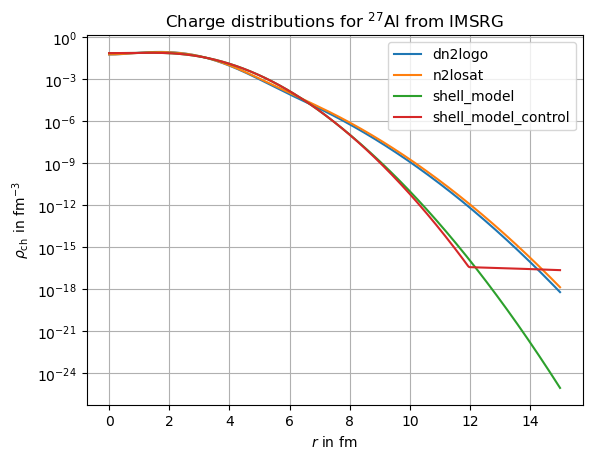

In [8]:
# Test if continuation of densities is smooth to high r.
r=np.arange(0,15,0.01)
for key in AI_dict:
    key_nucleus = AI_dict[key]['atom']
    response=key_nucleus.rhoM0p
    plt.plot(r,np.abs(response(r)),label=key)
plt.title('Charge distributions for $^{27}$Al from IMSRG')
plt.xlabel(r'$r$ in fm')
plt.ylabel(r'$\rho_{\operatorname{ch}}$ in fm$^{-3}$')
plt.grid()
#plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

-1.8394137553850003
-1.883324271178
-1.8526018
-1.8526018


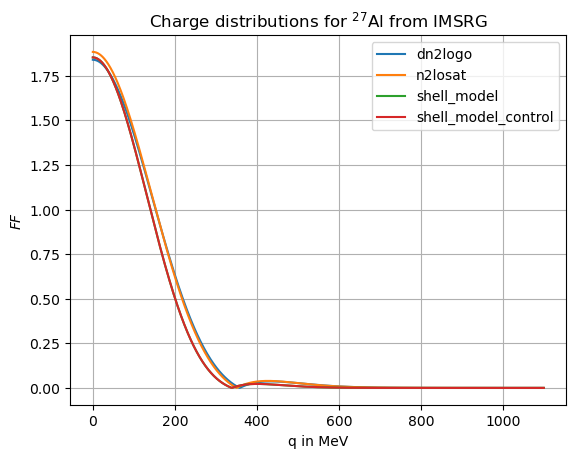

In [9]:
q=np.arange(0.,1100,1.)
spinp=0.326
spinn=0.038
J=5/2
for key in AI_dict:
    key_nucleus = AI_dict[key]['atom']
    response=key_nucleus.FPhipp0n
    plt.plot(q,np.abs(response(q)),label=key)
    #expectation=2*np.sqrt(1/3)*np.sqrt((J+1)/(J))*spinn
    print(response(0.))
#print('Expectation value of sigma for protons:', expectation)
plt.title('Charge distributions for $^{27}$Al from IMSRG')
plt.xlabel(r'q in MeV')
plt.ylabel(r'$FF$')
plt.grid()
plt.yscale('linear')
#plt.xlim(0,8)
plt.legend()
plt.show()

In [10]:
# Iterate over nuclear structure model
for AI_model in AI_dict:
    nucleus=AI_dict[AI_model]['atom']

    # Calculate electron wavefunctions for ejected electron
    AI_dict[AI_model]['ge']={}
    AI_dict[AI_model]['fe']={}
    for kappa in np.arange(-1,-2*nucleus.spin-3,-1,dtype=int):
        continuumstates = phr.continuumstates(nucleus,kappa=kappa,energy=mmu,verbose=False,potential_precision=1e-6)
        continuumstates.solve_IVP()
        AI_dict[AI_model]['ge'][str(kappa)] = continuumstates.wavefct_g
        AI_dict[AI_model]['fe'][str(kappa)] = continuumstates.wavefct_f

    # Calculate muon wavefunctions for bound muon
    boundstates = phr.boundstates(nucleus,kappa=-1,lepton_mass=mmu, verbose=False,potential_precision=1e-6)
    AI_dict[AI_model]['gmu']=boundstates.wavefunction_g_1s12
    AI_dict[AI_model]['fmu']=boundstates.wavefunction_f_1s12

In [11]:
# Definitions of overlap integrals
def overlap_integral(L,nuc,nucleus,verbose=False,lower_limit=0,upper_limit=np.inf,**args):
      type = args['type'] # scalar, vector or tensor
      leptonic = args['leptonic'] # determines the leptonic wavefunction combination
      operator = args['operator'] # hadronic operator
      response = args['response'] # Which multipole M,Phipp etc.
      dimfactor=1/(2*np.sqrt(2)*mmu**(2.))*hc**2

      # Return None for unavailable or failing currents so callers can skip this integral.
      def get_current_or_none(label):
            try:
                  current = getattr(nucleus,label)
                  current(1.)
            except Exception:
                  if verbose: print(f"Current {label} is not available for {AI_model}, skipping this integral.")
                  return None
            return current

      
      if 'modifier' in args.keys() and args['modifier'] is not None:
            if args['modifier']=='m2':
                  current_label='rhom2'+response+str(L)+nuc
            elif args['modifier']=='pi':
                  current_label='rhopi'+response+str(L)+nuc
      else:
             current_label='rho'+response+str(L)+nuc

      nucleon_current=get_current_or_none(current_label)
      if nucleon_current is None:
            return None
      
      
      Lfactor=1 # Prefactor depending on L
      trigger=0 # Counts how many times we have modified the Lfactor. It should be 0 or 1

      # scalar lepton current
      if type=='scalar':
            if leptonic=='g':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['fe'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='f':        
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['ge'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
      # vector lepton current
      elif type=='vector':
            if leptonic=='g':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['fe'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
                  if operator=='+':
                        leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-L)](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
                  elif operator=='-':
                        leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+2))](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['fe'][str(-(L+2))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='f':        
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['ge'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
                  if operator=='+':
                        leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L-1))](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['ge'][str(-(L-1))](x)*AI_dict[AI_model]['fmu'](x)
                  elif operator=='-':
                        leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L+1))](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='g-f':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='g+f':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+2))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='f-f':
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L-1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='f+f':
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='gf':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='ff':
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
            else:
                  raise ValueError('Invalid leptonic part')

            # Lfactor
            if response=='Delta':
                  if leptonic=='g-f' or leptonic=='f-f':
                        Lfactor=np.sqrt((L+1)/(2*L+1.))
                        trigger+=1
                  if leptonic=='g+f' or leptonic=='f+f':
                        Lfactor=np.sqrt(L/(2*L+1.))
                        trigger+=1
            elif response=='Sigmapp':
                  if operator=='+':
                        Lfactor=np.sqrt(L/(2*L+1.))
                        trigger+=1
                  if operator=='-':
                        Lfactor=np.sqrt((L+1.)/(2*L+1.))
                        trigger+=1
                  if operator=='bar':
                        Lfactor=np.sqrt(L*(L+1.))
                        trigger+=1
            elif response=='Sigmap':
                  if operator=='+':
                        Lfactor=np.sqrt((L+1.)/(2*L+1.))
                        trigger+=1
                  if operator=='-':
                        Lfactor=np.sqrt(L/(2*L+1.))
                        trigger+=1
                  if operator=='tilde':
                        Lfactor=1.
                        trigger+=1
                  if leptonic=='g-f' or leptonic=='f-f':
                        Lfactor=np.sqrt((L+1)/(2*L+1.))
                        trigger+=1
                  if leptonic=='g+f' or leptonic=='f+f':
                        Lfactor=np.sqrt(L/(2*L+1.))
                        trigger+=1
                  
      # tensor lepton current
      elif type=='tensor':
            if leptonic=='g':
                  if operator=='-':
                        leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+2))](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['fe'][str(-(L+2))](x)*AI_dict[AI_model]['fmu'](x)
                  elif operator=='+':
                        leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-L)](x)*AI_dict[AI_model]['gmu'](x)-AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='f':
                  if operator=='-':
                        leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L+1))](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
                  elif operator=='+':
                        leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-(L-1))](x)*AI_dict[AI_model]['gmu'](x)+AI_dict[AI_model]['ge'][str(-(L-1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='gf':
                  leptonic_part = lambda x: AI_dict[AI_model]['ge'][str(-(L+1))](x)*AI_dict[AI_model]['fmu'](x)
            elif leptonic=='ff':
                  leptonic_part = lambda x: AI_dict[AI_model]['fe'][str(-L)](x)*AI_dict[AI_model]['fmu'](x)
            
            #Lfactor
            if response=='M' or response=='Phipp' or response=='Sigmapp':
                  if operator=='+':
                        Lfactor=np.sqrt((L)/(2*L+1.))
                        trigger+=1
                  if operator=='-':
                        Lfactor=np.sqrt((L+1.)/(2*L+1.))
                        trigger+=1
                  if operator=='bar':
                        Lfactor=np.sqrt(L*(L+1.))
                        trigger+=1
            elif response=="Sigmap" or response=="Phip" or response=="Delta":
                  if operator=='+':
                        Lfactor=np.sqrt((L+1.)/(2*L+1.))
                        trigger+=1
                  if operator=='-':
                        Lfactor=np.sqrt(L/(2*L+1.))
                        trigger+=1
                  if operator=='tilde':
                        Lfactor=1.
                        trigger+=1
      else:
            raise ValueError('Invalid integral type')
      
      if trigger>1:
            raise ValueError('Lfactor has been modified more than once. Please check that there is no overlap in if conditions.')
      
      # Test leptonic current
      try:
            leptonic_part(1.)
      except Exception:
            if verbose: print(f"Leptonic part unavailable, skipping this integral.")
            return None
      
      if operator=='':
            return Lfactor*dimfactor*integrate.quad(lambda x: nucleon_current(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='bar':
            return Lfactor*dimfactor*integrate.quad(lambda x: hc/(x*mmu)*nucleon_current(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='tilde':
            derivative = lambda x: (nucleon_current(x+1e-6)-nucleon_current(x-1e-6))/(2*1e-6)
            return Lfactor*dimfactor*integrate.quad(lambda x: hc/mmu*(1/x*nucleon_current(x)+derivative(x))*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='pp': #one can feed in the laplacian of the structure function instead.
            current_label='rho2dot'+response+str(L)+nuc
            laplacian_dot = get_current_or_none(current_label)
            if laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: laplacian_dot(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='+':
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_plus(x,nucleon_current,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='-':
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_minus(x,nucleon_current,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      # composite operators
      elif operator=='+pp':
            current_label='rho2dot'+response+str(L)+nuc
            laplacian_dot = get_current_or_none(current_label)
            if laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_plus(x,laplacian_dot,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='-pp':
            current_label='rho2dot'+response+str(L)+nuc
            laplacian_dot = get_current_or_none(current_label)
            if laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_minus(x,laplacian_dot,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='barpp':
            current_label='rho2dot'+response+str(L)+nuc
            laplacian_dot = get_current_or_none(current_label)
            if laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: hc/(mmu*x)*laplacian_dot(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='tildepp':
            current_label='rho2dot'+response+str(L)+nuc
            laplacian_dot = get_current_or_none(current_label)
            if laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: 1/x*(hc/mmu)*laplacian_dot(x)*leptonic_part(x),lower_limit,upper_limit)[0] 
      elif operator=='4p':
            current_label='rho4dot'+response+str(L)+nuc
            double_laplacian_dot = get_current_or_none(current_label)
            if double_laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: double_laplacian_dot(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='+4p':
            current_label='rho4dot'+response+str(L)+nuc
            double_laplacian_dot = get_current_or_none(current_label)
            if double_laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_plus(x,double_laplacian_dot,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='-4p':
            current_label='rho4dot'+response+str(L)+nuc
            double_laplacian_dot = get_current_or_none(current_label)
            if double_laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: (hc/mmu)*nabla_dot_minus(x,double_laplacian_dot,L)*leptonic_part(x),lower_limit,upper_limit)[0]
      elif operator=='bar4p':
            current_label='rho4dot'+response+str(L)+nuc
            double_laplacian_dot = get_current_or_none(current_label)
            if double_laplacian_dot is None:
                  return None
            return Lfactor*dimfactor*integrate.quad(lambda x: hc/(mmu*x)*double_laplacian_dot(x)*leptonic_part(x),lower_limit,upper_limit)[0]
      else:
            raise ValueError('Invalid operator')




In [19]:
# Auxilary functions for overlap integrals
def format_value_error(value, errors, labels=None, digits=2):
    """
    Format a value and one or more uncertainties in LaTeX math mode (no surrounding $).
    Show the coefficient (with its rounded decimals) followed immediately by
    uncertainty parenthesis and optional subscript labels, then the power of ten,
    e.g. "1.6161(86)_{m}(17)_{ex} \\times 10^{-2}" (returned without $ so Math() can wrap it).
    """
    errors = np.abs(np.array(errors, dtype=float))

    if isinstance(labels, str):
        labels = [labels]
    if labels is None:
        labels = [None] * len(errors)
    else:
        labels = list(labels)

    if len(labels) != len(errors):
        raise ValueError("labels must have the same length as errors")
    if digits < 1:
        raise ValueError("digits must be >= 1")

    # short label map for LaTeX subscripts (customize as needed)
    label_map = {'model': 'm', 'ex': 'ex'}

    value = float(value)
    if value != 0:
        value_exp = int(np.floor(np.log10(abs(value))))
    elif errors.size > 0 and np.max(errors) > 0:
        value_exp = int(np.floor(np.log10(float(np.max(errors)))))
    else:
        value_exp = 0

    # No uncertainties -> still show scientific notation (raw LaTeX, no $)
    if errors.size == 0 or float(np.max(errors)) == 0:
        formatted_val = f"{value / (10 ** value_exp):.{max(2, digits)}f}\\times 10^{{{value_exp}}}"
        return formatted_val

    # Determine exponent units for uncertainties and number of decimals to show
    max_error = float(np.max(errors))
    max_error_exp = int(np.floor(np.log10(max_error)))
    unit_exp = max_error_exp - digits + 1
    value_decimals = max(0, value_exp - unit_exp)

    value_scaled = value / (10 ** value_exp)
    # coefficient string (no $), uncertainties will be appended directly
    coeff_str = f"{value_scaled:.{value_decimals}f}"

    # Build uncertainty suffix immediately after coefficient
    suffix_parts = []
    for error, label in zip(errors, labels):
        error = float(abs(error))
        error_digits = int(np.rint(error / (10 ** unit_exp))) if error > 0 else 0
        if error_digits == 0:
            continue
        if label is None:
            suffix_parts.append(f"({error_digits})")
        else:
            mapped = label_map.get(label, label)
            suffix_parts.append(f"({error_digits})_{{{mapped}}}")

    if len(suffix_parts) > 0:
        coeff_with_unc = coeff_str + ''.join(suffix_parts)
    else:
        coeff_with_unc = coeff_str

    final = f"{coeff_with_unc} \\times 10^{{{value_exp}}}"
    return final

def print_oi(L, nuc, value, errors=None, labels=None):

    if errors is not None:
        formatted = format_value_error(value, errors, labels=labels, digits=2)
        display(Math(rf"{L}{nuc}:\;{formatted}"))
    else:
        display(Math(rf"{L}{nuc}:\;{value:.3e}"))


def calculate_and_store_overlap_integrals(
    AI_dict,
    result_dict,
    verbose=False,
    **kws
):
    """
    Generalized function to calculate overlap integrals and store statistics.
    
    Parameters
    ----------
    AI_dict : dict
        Dictionary containing ab initio models as keys
    result_dict : defaultdict
        Dictionary to store results (should be a nested defaultdict like SI, VI, or TI)
    verbose : bool, optional
        If True, print results using print_oi function (default: False)
    **kws : keyword arguments
        Must contain:
        - L : int, angular momentum quantum number
        - nuc : str, nucleon ('p' or 'n')
        - type : str, integral type ('scalar', 'vector', 'tensor')
        - response : str, response function type
        - leptonic : str, leptonic part
        - operator : str, operator type ('' for default)
        
        Optional:
        - print_oi : callable, function to print results (if verbose=True)
    
    Returns
    -------
    dict
        The updated result dictionary.
    
    Notes
    -----
    This function requires the overlap_integral function to be available in the
    calling scope. The result_dict is modified in-place.
    
    Examples
    --------
    >>> result = calculate_and_store_overlap_integrals(
    ...     AI_dict,
    ...     SI,
    ...     verbose=True,
    ...     L=0,
    ...     nuc='p',
    ...     type='scalar',
    ...     response='M',
    ...     leptonic='g',
    ...     operator='',
    ...     print_oi=print_oi
    ... )
    """
    
    # Extract keyword arguments
    L = kws['L']
    nuc = kws['nuc']
    integral_type = kws['type']
    response = kws['response']
    leptonic = kws['leptonic']
    operator = kws['operator']
    modifier = kws.get('modifier', None)
    
    # Build the dictionary key structure
    L_str = str(L)
    
    leptonic_key = leptonic + operator
    response_key = response if modifier is None else response + '_' + modifier
    if modifier is not None:
        cutoff_key = modifier+response + str(L) + nuc
    elif operator=='' or operator=='+' or operator=='-' or operator=='tilde' or operator=='bar':
        cutoff_key = response + str(L) + nuc
    elif operator=='pp' or operator=='+pp' or operator=='-pp' or operator=='barpp' or operator=='tildepp':
        cutoff_key = '2dot' + response + str(L) + nuc
    elif operator=='4p' or operator=='+4p' or operator=='-4p' or operator=='bar4p':
        cutoff_key = '4dot' + response + str(L) + nuc
    else:
        raise ValueError('Case not treated')
    
    # Calculate overlap integrals for each AI model and store individual results
    overlap_list = {'values': {}, 'extrapolation_errors': {}}
    for AI_model in AI_dict:
        try:    
            nucleus = AI_dict[AI_model]['atom'] 
            overlap_list['values'][AI_model] = overlap_integral(
                L,
                nuc,
                nucleus,
                lower_limit=0,
                upper_limit=np.inf,
                verbose=verbose,
                type=integral_type,
                response=response,
                leptonic=leptonic,
                operator=operator,
                modifier=modifier
            )
            if overlap_list['values'][AI_model] is None:
                overlap_list['values'].pop(AI_model)
        except (KeyError, Exception) as e:
            result_dict[AI_model][L_str][nuc][leptonic_key][response_key] = None
            
        for AI_model in overlap_list['values']:
            result_dict[AI_model][L_str][nuc][leptonic_key][response_key] = overlap_list['values'][AI_model]
            if 'shell_model' in overlap_list['values'] and 'shell_model_control' in overlap_list['values']:
                integral= overlap_list['values']['shell_model']
                control_integral=overlap_list['values']['shell_model_control']
                if integral!=0:
                    overlap_list['extrapolation_errors'][AI_model] = abs((integral-control_integral)/integral)*overlap_list['values'][AI_model]
    
    # Don't consider the shell model to the calculation of average and error
    overlap_list['values'].pop('shell_model', None)
    overlap_list['values'].pop('shell_model_control', None)

    overlap_list['extrapolation_errors'].pop('shell_model', None)
    overlap_list['extrapolation_errors'].pop('shell_model_control', None)

    values=list(overlap_list['values'].values())
    extrapolation_errors=list(overlap_list['extrapolation_errors'].values())
    
    if len(overlap_list['values']) > 0:
        mean_value = np.mean(values)
        model_error = (np.max(values)-np.min(values))
    else:
        mean_value = None
        model_error = None

    if len(extrapolation_errors) > 0:
        extrapolation_error = np.mean(extrapolation_errors) # holds for fully correlated errors
    else:
        extrapolation_error = None
    
    # Store statistics
    result_dict['mean'][L_str][nuc][leptonic_key][response_key] = mean_value
    result_dict['model_error'][L_str][nuc][leptonic_key][response_key] = model_error
    # holds for fully correlated errors
    result_dict['extrapolation_error'][L_str][nuc][leptonic_key][response_key] = extrapolation_error
    
    # Print if verbose and print_oi is provided
    if verbose and len(overlap_list['values']) > 0:
        error_list=[model_error, extrapolation_error]
        for i in range(len(error_list)):
            if error_list[i] is None:
                error_list[i] = 0.0 # It will not appear in printout
        print_oi(L, nuc, mean_value, error_list, ['model', 'ex'])
    
    # Return the updated accumulator, not the innermost response dict.
    return result_dict

In [20]:
# Evaluate overlap integrals
latex_label = {
    "M": "M",
    "Phipp": r"\Phi^{\prime\prime}",
    "Phip": r"\Phi^{\prime}",
    "Delta": r"\Delta",
    "Sigmap": r"\Sigma^{\prime}",
    "Sigmapp": r"\Sigma^{\prime\prime}",
}


def zero_oi():
    return defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(float)))))


SI = zero_oi()
VI = zero_oi()
TI = zero_oi()
Lmax = int(2*nucleus.spin)

# Scalar integrals
for leptonic in ['g','f']:
    for response in ["M", "Phipp","Sigmapp"]:
        display(Math(rf"S_{{{leptonic}}}^{{{latex_label[response]}}}"))
        if response == "Sigmapp":
            L_list = np.arange(1, Lmax + 1, 2, dtype=int)
        else:
            L_list = np.arange(0, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                SI=calculate_and_store_overlap_integrals(AI_dict,SI,verbose=True,L=L,nuc=nuc,type='scalar',response=response,leptonic=leptonic,operator='')

for leptonic in ['g','f']:
    for response in ["M", "Phipp", "Sigmapp"]:
        display(Math(r"S_{" + leptonic + r"}^{" + r"\prime\prime " + latex_label[response] + r"}"))
        if response == "Sigmapp":
            L_list = np.arange(1, Lmax + 1, 2, dtype=int)
        else:
            L_list = np.arange(0, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                SI=calculate_and_store_overlap_integrals(AI_dict,SI,verbose=True,L=L,nuc=nuc,type='scalar',response=response,leptonic=leptonic,operator='pp')

response = "Sigmapp"
for leptonic in ['g','f']:
    display(Math(r"S_{" + leptonic + r"}^{" + latex_label[response] + r",\pi" + r"}"))
    L_list = np.arange(1, Lmax + 1, 2, dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            SI=calculate_and_store_overlap_integrals(AI_dict,SI,verbose=True,L=L,nuc=nuc,type='scalar',response=response,leptonic=leptonic,operator='',modifier='pi')

for leptonic in ['g','f']:
    display(Math(r"S_{" + leptonic + r"}^{" + "(4)," + latex_label[response] + r"}"))
    L_list = np.arange(1, Lmax + 1, 2, dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            SI=calculate_and_store_overlap_integrals(AI_dict,SI,verbose=True,L=L,nuc=nuc,type='scalar',response=response,leptonic=leptonic,operator='4p')

# Vector integrals
for leptonic in ['g','f']:
    for response in ["M"]:
        display(Math(r"V_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
        L_list = np.arange(0, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator='')

for leptonic in ['g','f']:
    for response in ["M", "Phipp"]:
        display(Math(r"V_{" + leptonic + r"}^{" + r"\prime \prime " + latex_label[response] + r"}"))
        L_list = np.arange(0, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator='pp')

for leptonic in ['g','f','g-f','f-f','g+f','f+f']:
    for response in ["Delta"]:
        display(Math(r"V_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
        L_list = np.arange(1, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator='')

response= "Sigmapp"
for tuple in [('g','+'),('g','-'),('f','+'),('f','-'),('gf','bar'),('ff','bar')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='bar':
        display(Math(r"\bar{V}_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
    else:
        display(Math(r"V_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))
    L_list=np.arange(1,Lmax+1,2,dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator=operator)

for tuple in [('g','+'),('f','-'),('gf','bar'),('ff','bar')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='bar':
        display(Math(r"\bar{V}_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
    else:
        display(Math(r"V_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))
    L_list=np.arange(1,Lmax+1,2,dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator=operator,modifier='pi')

for tuple in [('g','+pp'),('g','-pp'),('f','+pp'),('f','-pp'),('gf','barpp'),('ff','barpp')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='barpp':
        display(Math(r"\bar{V}_{" + leptonic + r"}^{" + r"\prime" + r"\prime" + latex_label[response] + r"}"))
    else:
        display(Math(r"V_{" + leptonic + r"}^{" + operator[0] + r"\prime" + r"\prime" + latex_label[response] + r"}"))
    L_list=np.arange(1,Lmax+1,2,dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator=operator)


response = "Sigmap"
for leptonic in ['g','f']:
    for operator in ['+','-']:
        display(Math(r"V_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))
        L_list=np.arange(1,Lmax+1,2,dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator=operator)

for leptonic in ['gf','ff']:
        display(Math(r"\tilde{V}_{" + leptonic + r"}^{" + " " + latex_label[response] + r"}"))
        L_list=np.arange(1,Lmax+1,2,dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator='tilde')
                
for leptonic in ['g','f','g-f','f-f','g+f','f+f']:
    display(Math(r"V_{" + leptonic + r"}^{" + r"\prime \prime " + latex_label[response] + r"}"))
    L_list=np.arange(1,Lmax+1,2,dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator='pp')

for tuple in [('g','+pp'),('f','-pp'),('gf','tildepp'),('ff','tildepp')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='tildepp':
        display(Math(r"\tilde{V}_{" + leptonic + r"}^{" + r"\prime" + r"\prime" + latex_label[response] + r"}"))
    else:
        display(Math(r"V_{" + leptonic + r"}^{" + operator[0] + r"\prime" + r"\prime" + latex_label[response] + r"}"))
    L_list=np.arange(1,Lmax+1,2,dtype=int)
    for L in L_list:
        for nuc in ['p','n']:
            VI=calculate_and_store_overlap_integrals(AI_dict,VI,verbose=True,L=L,nuc=nuc,type='vector',response=response,leptonic=leptonic,operator=operator)


# Tensor integrals
for response in ["M", "Phipp", "Sigmapp"]:
    for tuple in [('g','+'),('g','-'),('f','+'),('f','-'),('gf','bar'),('ff','bar')]:
        leptonic = tuple[0]; operator = tuple[1]
        if operator=='bar':
            display(Math(r"\bar{T}_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
        else:
            display(Math(r"T_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))
        if response == "Sigmapp":
            L_list = np.arange(1, Lmax + 1, 2, dtype=int)
        else:
            L_list = np.arange(0, Lmax + 1, 2, dtype=int)
        for L in L_list:
            for nuc in ['p','n']:
                TI=calculate_and_store_overlap_integrals(AI_dict,TI,verbose=True,L=L,nuc=nuc,type='tensor',response=response,leptonic=leptonic,operator=operator)
"""
for response in ["Sigmap","Phip"]:
    if response=="Phip":
        L_list=np.arange(2,Lmax+1,2,dtype=int)
    else:
        L_list=np.arange(1,Lmax+1,2,dtype=int)
    for tuple in [('g','+'),('g','-'),('f','+'),('f','-'),('gf','tilde'),('ff','tilde')]:
        leptonic = tuple[0]; operator = tuple[1]
        if operator=='tilde':
            display(Math(r"\tilde{T}_{" + leptonic + r"}^{" + latex_label[response] + r"}"))
        else:
            display(Math(r"T_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))
        for L in L_list:
            for nuc in ['p','n']:
                TI=calculate_and_store_overlap_integrals(AI_dict,TI,verbose=True,L=L,nuc=nuc,type='tensor',response=response,leptonic=leptonic,operator=operator)
"""

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Current rhoM2p is not available for shell_model_control, skipping this integral.
Current rhoM2p is not available for shell_model_control, skipping this integral.


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

'\nfor response in ["Sigmap","Phip"]:\n    if response=="Phip":\n        L_list=np.arange(2,Lmax+1,2,dtype=int)\n    else:\n        L_list=np.arange(1,Lmax+1,2,dtype=int)\n    for tuple in [(\'g\',\'+\'),(\'g\',\'-\'),(\'f\',\'+\'),(\'f\',\'-\'),(\'gf\',\'tilde\'),(\'ff\',\'tilde\')]:\n        leptonic = tuple[0]; operator = tuple[1]\n        if operator==\'tilde\':\n            display(Math(r"\tilde{T}_{" + leptonic + r"}^{" + latex_label[response] + r"}"))\n        else:\n            display(Math(r"T_{" + leptonic + r"}^{" + operator + " " + latex_label[response] + r"}"))\n        for L in L_list:\n            for nuc in [\'p\',\'n\']:\n                TI=calculate_and_store_overlap_integrals(AI_dict,TI,verbose=True,L=L,nuc=nuc,type=\'tensor\',response=response,leptonic=leptonic,operator=operator)\n'

In [ ]:
# Integrals with tilde responses
response = "M"
for tuple in [('g','+'),('g','-'),('f','+'),('f','-'),('gf','bar'),('ff','bar')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='bar':
        display(Math(r"\bar{T}_{" + leptonic + r"}^{" + r"\tilde{" + latex_label[response] + r"}" + r"}"))
    else:
        display(Math(r"T_{" + leptonic + r"}^{" + operator + r"\tilde{" + latex_label[response] + r"}" + r"}"))
    L_list=np.arange(0, Lmax+1 , 2,dtype=int)
    for L in L_list:
        nuc = 'p'  # Only proton tilde currents are available in the current AI_dict
        TI=calculate_and_store_overlap_integrals(AI_dict,TI,verbose=True,L=L,nuc=nuc,type='tensor',response=response,leptonic=leptonic,operator=operator,modifier='m2')

response = "Delta"
for tuple in [('g','+'),('g','-'),('f','+'),('f','-'),('gf','tilde'),('ff','tilde')]:
    leptonic = tuple[0]; operator = tuple[1]
    if operator=='tilde':
        display(Math(r"\tilde{T}_{" + leptonic + r"}^{\tilde{" + latex_label[response] + r"}}"))
    else:
        display(Math(r"T_{" + leptonic + r"}^{" + operator + r"\tilde{" + latex_label[response] + r"}" + r"}"))
    L_list=np.arange(1, Lmax+1 , 2,dtype=int)
    for L in L_list:
        nuc = 'p'  # Only proton tilde currents are available in the current AI_dict
        TI=calculate_and_store_overlap_integrals(AI_dict,TI,verbose=True,L=L,nuc=nuc,type='tensor',response=response,leptonic=leptonic,operator=operator,modifier='m2')

<IPython.core.display.Math object>

Leptonic part unavailable, skipping this integral.
Leptonic part unavailable, skipping this integral.
Leptonic part unavailable, skipping this integral.
Leptonic part unavailable, skipping this integral.
Leptonic part unavailable, skipping this integral.
Leptonic part unavailable, skipping this integral.
Current rhom2M2p is not available for shell_model, skipping this integral.
Current rhom2M2p is not available for shell_model, skipping this integral.


<IPython.core.display.Math object>

Current rhom2M4p is not available for shell_model, skipping this integral.
Current rhom2M4p is not available for shell_model, skipping this integral.


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

Current rhom2Delta3p is not available for shell_model, skipping this integral.
Current rhom2Delta3p is not available for shell_model, skipping this integral.


<IPython.core.display.Math object>

Current rhom2Delta5p is not available for shell_model, skipping this integral.
Current rhom2Delta5p is not available for shell_model, skipping this integral.


<IPython.core.display.Math object>

In [28]:
# Export overlap integrals to two PDFs (even and odd L) using print_oi-style formatting
"""
short_map = {'SI': 'S', 'VI': 'V', 'TI': 'T'}
even_group = ['M', 'Phipp']
odd_group = ['Sigmapp', 'Sigmap', 'Delta']
oi_names = ['SI','VI','TI']
oi_maps = {'SI': SI, 'VI': VI, 'TI': TI}

def response_keys_in_order(resp_dict, response):
    keys = [key for key in resp_dict.keys() if key == response or str(key).startswith(response + '_')]
    if response in keys:
        ordered = [response]
        keys = [key for key in keys if key != response]
    else:
        ordered = []
    return ordered + sorted(keys, key=str)

# Type ordering helpers (reuse prior ordering lists)
leptonic_type_order = ['f', 'g', 'ff', 'gf', 'f-f', 'g-f', 'f+f', 'g+f', 'f+', 'g+', 'f-', 'g-', 'ffbar', 'gfbar', 'fftilde', 'gftilde']
operator_order = ['', 'pp', '4p', 'bar', 'tilde', '+pp', '-pp', 'barpp', 'tildepp']

def split_type_key(key):
    key = str(key)
    for leptonic_key in sorted(leptonic_type_order, key=len, reverse=True):
        if key == leptonic_key:
            return leptonic_key, ''
        if key.startswith(leptonic_key):
            operator_key = key[len(leptonic_key):]
            return leptonic_key, operator_key
    return key, ''

def type_key_sort(key):
    leptonic_key, operator_key = split_type_key(key)
    try:
        leptonic_rank = leptonic_type_order.index(leptonic_key)
    except ValueError:
        leptonic_rank = len(leptonic_type_order)
    try:
        operator_rank = operator_order.index(operator_key)
    except ValueError:
        operator_rank = len(operator_order)
    return (leptonic_rank, operator_rank, str(key))

def collect_leptonic_keys(OI):
    keys = set()
    for L in OI.keys():
        for nuc in OI[L].keys():
            keys.update(OI[L][nuc].keys())
    return sorted(list(keys), key=type_key_sort)

def format_integral_type_label(oi_short, type , leptonic, operator , response, nuc, modifier=None):

    type_map = {'scalar': 'S', 'vector': 'V', 'tensor': 'T','else':'X'}
    
    response_map={ "M": "M",
    "Phipp": r"\Phi^{\prime\prime}",
    "Phip": r"\Phi^{\prime}",
    "Delta": r"\Delta",
    "Sigmap": r"\Sigma^{\prime}",
    "Sigmapp": r"\Sigma^{\prime\prime}",
    }
    modifier_map = {
        'pi': r"\pi",
        'm2': r"\gamma",
    }
    operator_map = {
        '': '',
        'pp': r"\prime\prime",
        '4p': r"(4)",
        'bar': r"\bar",
        'tilde': r"\tilde",
        '+pp': r"+\prime\prime",
        '-pp': r"-\prime\prime",
        'barpp': r"\bar\prime\prime",
        'tildepp': r"\tilde\prime\prime",
    }
    base = type_map.get(type, 'X')
    response_tex = latex_label[response]
    if modifier is not None:
        response_tex = modifier_map.get(modifier, modifier) + ',' + response_tex

    if operator == 'bar' or operator == 'barpp':
        base = rf'\bar{{{base}}}'
        operator=operator[3:]  # remove 'bar' prefix for operator_tex
    elif operator == 'tilde' or operator == 'tildepp':
        base = rf'\tilde{{{base}}}'
        operator=operator[5:] 

    return rf'{base}_{{{leptonic}}}^{{{operator},{response_tex}_{nuc}}}'

# Helper to safely fetch nested entries from result dictionaries
def get_nested(d, Ls, nuc, leptonic_key, response_name):
    try:
        return d[Ls][nuc][leptonic_key].get(response_name)
    except Exception:
        return None

# Determine average q_cutoff and r_cut for filenames/title
q_cutoff_val = globals().get('q_cutoff', None)
r_cut_val = globals().get('r_cut', None)
q_cutoff_avg = np.mean(list(q_cutoff_val.values())) if hasattr(q_cutoff_val, 'values') and len(q_cutoff_val) > 0 else q_cutoff_val
r_cut_avg = np.mean(list(r_cut_val.values())) if hasattr(r_cut_val, 'values') and len(r_cut_val) > 0 else r_cut_val

def build_and_save_table(group_name, responses, L_list):
    columns = ['type'] + [f'L={L}' for L in L_list]
    rows = []
    for response in responses:
        for OI_name in oi_names:
            oi_full = oi_maps.get(OI_name)
            if oi_full is None:
                continue
            OI = oi_full.get('mean', {})
            model_errs = oi_full.get('model_error', {})
            extrap_errs = oi_full.get('extrapolation_error', {})
            oi_short = short_map.get(OI_name, OI_name)
            if not OI:
                continue
            leptonic_keys = collect_leptonic_keys(OI)
            for leptonic_key in leptonic_keys:
                for nuc in ['p', 'n']:
                    row = [format_integral_type_label(oi_short, leptonic_key, response)]
                    any_value = False
                    for L in L_list:
                        Ls = str(L)
                        cell_val = ''
                        if Ls in OI and nuc in OI[Ls] and leptonic_key in OI[Ls][nuc]:
                            resp_dict = OI[Ls][nuc][leptonic_key]
                            for response_name in response_keys_in_order(resp_dict, response):
                                val = resp_dict.get(response_name)
                                if val is None:
                                    continue
                                # fetch errors from corresponding dicts
                                model_err = get_nested(model_errs, Ls, nuc, leptonic_key, response_name)
                                extrap_err = get_nested(extrap_errs, Ls, nuc, leptonic_key, response_name)
                                # prepare errors list similar to print_oi behaviour
                                errs = [model_err if model_err is not None else 0.0, extrap_err if extrap_err is not None else 0.0]
                                try:
                                    formatted = format_value_error(val, errs, labels=['m','ex'], digits=2)
                                except Exception:
                                    formatted = str(val)
                                cell_val = formatted
                                any_value = True
                                break
                        row.append(cell_val)
                    if any_value:
                        rows.append(row)

    fig, ax = plt.subplots(figsize=(11, max(2, len(rows)*0.25)))
    ax.axis('off')
    if len(rows) == 0:
        ax.text(0.5, 0.5, 'No overlap-integral entries found for ' + group_name, ha='center', va='center')
    else:
        table = ax.table(cellText=rows, colLabels=columns, cellLoc='left', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.2)
        # Ensure LaTeX/mathtext is used for data cells: wrap each data cell text in $...$ so matplotlib renders math
        nrows = len(rows)
        ncols = len(columns)
        for i in range(nrows):
            for j in range(ncols):
                cell = table[(i+1, j)]  # data rows start at row index 1 (row 0 are headers)
                txt = cell.get_text().get_text()
                if txt is None or txt.strip() == '':
                    continue
                # If the string already contains $ delimiters, leave it; otherwise wrap it
                if not (txt.startswith('$') and txt.endswith('$')):
                    cell.get_text().set_text(rf"${txt}$")
    title = f'Overlap integrals ({group_name}) - q_cutoff={q_cutoff_avg}, r_cut={r_cut_avg}'
    plt.title(title)
    plt.tight_layout()
    outfile = f'overlap_integrals_{group_name}_q{q_cutoff_avg}_r{r_cut_avg}.pdf'
    fig.savefig(outfile)
    print('Saved', outfile)

# Build even and odd L lists from nucleus spin (use first AI model available)
Lmax_val = int(2 * list(AI_dict.values())[0]['atom'].spin)
even_Ls = list(np.arange(0, Lmax_val + 1, 2, dtype=int))
odd_Ls = list(np.arange(1, Lmax_val + 1, 2, dtype=int))

build_and_save_table('even', even_group, even_Ls)
build_and_save_table('odd', odd_group, odd_Ls)
"""

<>:56: SyntaxWarning: invalid escape sequence '\P'
<>:56: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_26679/2040659091.py:56: SyntaxWarning: invalid escape sequence '\P'
  "Phipp": r"\Phi^{\prime\prime}",


'\nshort_map = {\'SI\': \'S\', \'VI\': \'V\', \'TI\': \'T\'}\neven_group = [\'M\', \'Phipp\']\nodd_group = [\'Sigmapp\', \'Sigmap\', \'Delta\']\noi_names = [\'SI\',\'VI\',\'TI\']\noi_maps = {\'SI\': SI, \'VI\': VI, \'TI\': TI}\n\ndef response_keys_in_order(resp_dict, response):\n    keys = [key for key in resp_dict.keys() if key == response or str(key).startswith(response + \'_\')]\n    if response in keys:\n        ordered = [response]\n        keys = [key for key in keys if key != response]\n    else:\n        ordered = []\n    return ordered + sorted(keys, key=str)\n\n# Type ordering helpers (reuse prior ordering lists)\nleptonic_type_order = [\'f\', \'g\', \'ff\', \'gf\', \'f-f\', \'g-f\', \'f+f\', \'g+f\', \'f+\', \'g+\', \'f-\', \'g-\', \'ffbar\', \'gfbar\', \'fftilde\', \'gftilde\']\noperator_order = [\'\', \'pp\', \'4p\', \'bar\', \'tilde\', \'+pp\', \'-pp\', \'barpp\', \'tildepp\']\n\ndef split_type_key(key):\n    key = str(key)\n    for leptonic_key in sorted(leptonic_type_or